---
# COSC2673 (Computational) Machine Learning - Assignment 1 
## Airbnb Price Prediction By Alissa Nguyen (s4085541)
---

### Introduction
This assignment focuses on developing regression models to predict Airbnb listing prices using a real world dataset. This problem is set up as a supervised learning regression task because the target variable, *price*, is continuous.

The 3 models are to be implemented and evaluated: 
- Linear Regression
- Ridge Regression
- Lasso Regression
  
These models are compared using validation metrics to determine which offers the best predictive performance.

### Instructions

Before running the model, ensure that:
1. A Python environment is (Anaconda or standard Python with Jupyter Notebook) 
2. Install the following libraries:
- pandas
- numpy
- matplotlib
- scikit-learn
  
3. Download the data files (train_data.csv and test_data.csv ) into your working directory.

To run this notebook:

4. Start jupyter notebook/lab
5. Run the cells from top to bottom order
6. The notebook will automatically do the following:
- data loading and preprocessing
- models training and evaluating
- model comparison
- choose the optimal model
- generate predictions on the test data
  
7. The predicted data will be automatically saved as csv file called “s4085541_predictions.csv”


### 1. Import Libraries

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score

### 2. Set up: load data

In [2]:
train_df = pd.read_csv("train_data.csv")
test_df = pd.read_csv("test_data.csv")

### 3. Inspection

the training and test datasets are inspected to verify that they have been loaded correctly and to better understand their structure.

the `.head()` function is used to preview sample rows, while `.info()` and `.shape` provide information about:
- the number of observations
- feature types (numerical vs categorical)
- presence of missing values

In [3]:
train_df.head()

,host_is_superhost,city,country,latitude,longitude,room_type,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,number_of_reviews,review_scores_rating,instant_bookable,calculated_host_listings_count
0,f,Kingston,Australia,-38.022565,145.098937,Entire home/apt,5,1.0,2.0,4.0,111,3,28,94.0,t,1
1,f,Yarra,Australia,-37.782125,144.988079,Entire home/apt,3,1.0,1.0,1.0,80,1,59,93.0,t,1
2,t,Port Phillip,Australia,-37.853710,144.981529,Entire home/apt,4,1.0,1.0,2.0,150,2,14,100.0,f,1
3,f,Glen Eira,Australia,-37.876393,145.036635,Entire home/apt,2,1.0,1.0,1.0,125,1,39,97.0,f,55
4,f,Melbourne,Australia,-37.810398,144.950113,Entire home/apt,3,1.0,1.0,2.0,79,3,7,97.0,t,1


In [4]:
test_df.head()

,host_is_superhost,city,country,latitude,longitude,room_type,accommodates,bathrooms,bedrooms,beds,minimum_nights,number_of_reviews,review_scores_rating,instant_bookable,calculated_host_listings_count
0,f,Moreland,Australia,-37.766505,144.980736,Private room,2,1.0,1.0,1.0,3,108,87.0,t,1
1,t,Port Phillip,Australia,-37.859755,144.977369,Entire home/apt,3,1.0,1.0,2.0,3,15,94.0,f,17
2,f,Port Phillip,Australia,-37.864530,144.992238,Private room,2,1.0,1.0,2.0,1,63,90.0,f,1
3,f,Darebin,Australia,-37.697294,145.000816,Private room,2,1.0,1.0,1.0,7,159,94.0,f,3
4,f,Melbourne,Australia,-37.810267,144.985920,Private room,2,1.0,1.0,1.0,1,3,93.0,f,1


In [5]:
print("Training data shape:", train_df.shape)
print("Test data shape:", test_df.shape)

Training data shape: (8586, 16)
Test data shape: (8585, 15)


In [6]:
print(train_df.columns.tolist())
print(test_df.columns.tolist())

['host_is_superhost', 'city', 'country', 'latitude', 'longitude', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price', 'minimum_nights', 'number_of_reviews', 'review_scores_rating', 'instant_bookable', 'calculated_host_listings_count']
['host_is_superhost', 'city', 'country', 'latitude', 'longitude', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 'review_scores_rating', 'instant_bookable', 'calculated_host_listings_count']


In [22]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8586 entries, 0 to 8585
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   host_is_superhost               8586 non-null   object 
 1   city                            8586 non-null   object 
 2   country                         8586 non-null   object 
 3   latitude                        8586 non-null   float64
 4   longitude                       8586 non-null   float64
 5   room_type                       8586 non-null   object 
 6   accommodates                    8586 non-null   int64  
 7   bathrooms                       8586 non-null   float64
 8   bedrooms                        8586 non-null   float64
 9   beds                            8586 non-null   float64
 10  price                           8586 non-null   int64  
 11  minimum_nights                  8586 non-null   int64  
 12  number_of_reviews               85

In [76]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8585 entries, 0 to 8584
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   host_is_superhost               8585 non-null   object 
 1   city                            8585 non-null   object 
 2   country                         8585 non-null   object 
 3   latitude                        8585 non-null   float64
 4   longitude                       8585 non-null   float64
 5   room_type                       8585 non-null   object 
 6   accommodates                    8585 non-null   int64  
 7   bathrooms                       8585 non-null   float64
 8   bedrooms                        8585 non-null   float64
 9   beds                            8585 non-null   float64
 10  minimum_nights                  8585 non-null   int64  
 11  number_of_reviews               8585 non-null   int64  
 12  review_scores_rating            85

based off this inspection: 
- the training dataset contains the target variable *price*, but the test dataset does not
- the dataset includes a mix of numerical features (*latitude*, *accommodates*) and categorical features (*room_type*, *city*)
- no missing values are observed, but preprocessing steps are still applied to ensure robustness

### 4. Data Analysis

This exploratory data analysis is done to better understand the distribution of the target variable and the relationships between features. This helps support preprocessing choices and provides insight into factors that may affect model performance.

**4.1 Price Distribution**

The distribution of `price` appears right-skewed, with many lower priced listings and fewer very expensive listings. This suggests that extreme prices may be harder for linear models to predict accurately.

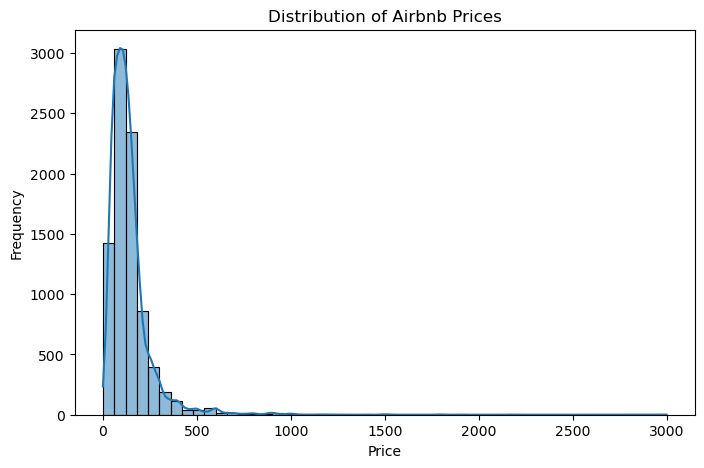

In [30]:
plt.figure(figsize=(8,5))
sns.histplot(train_df["price"], bins=50, kde=True)
plt.title("Distribution of Airbnb Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

**4.2 Correlation heatmap**

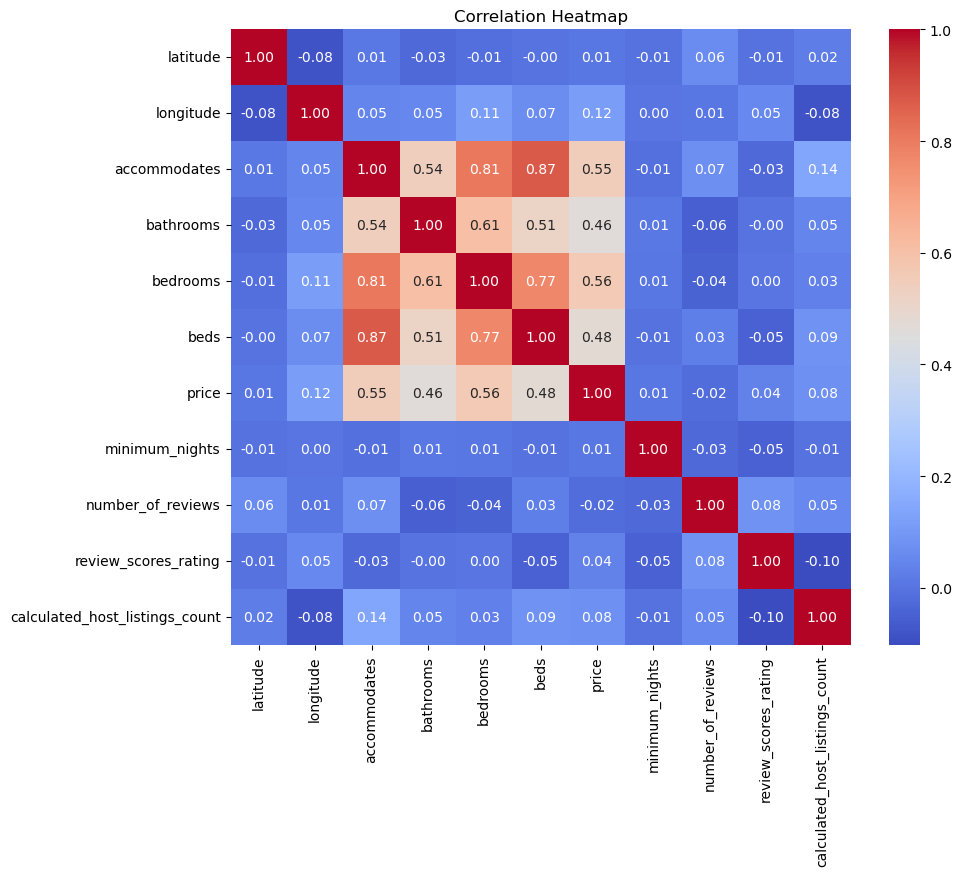

In [31]:
plt.figure(figsize=(10,8))
corr = train_df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**4.3 Room type vs price** 

The boxplot shows that room type can influence listing price. Entire home or apartment listings generally seem more expensive than private rooms, suggesting that categorical variables contribute useful information.

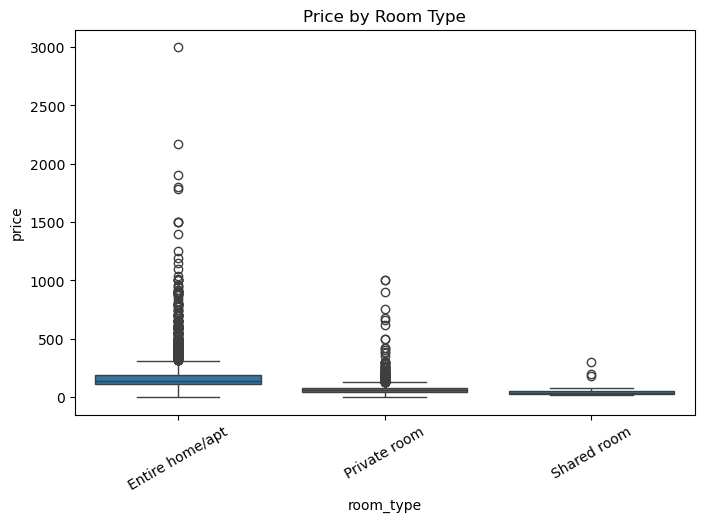

In [32]:
plt.figure(figsize=(8,5))
sns.boxplot(x="room_type", y="price", data=train_df)
plt.title("Price by Room Type")
plt.xticks(rotation=30)
plt.show()

**4.4 Accommodates vs price**

Listings that accommodate more guests generally tend to have higher prices, although there is considerable variation. This indicates that accommodates is relevant, but not sufficient on its own to explain price.

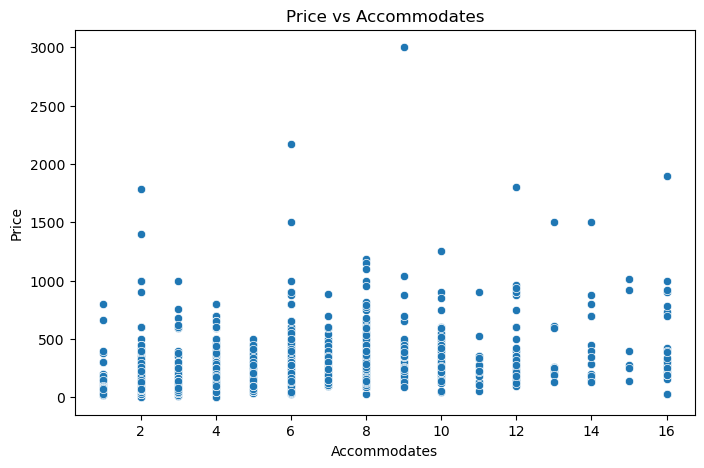

In [33]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="accommodates", y="price", data=train_df)
plt.title("Price vs Accommodates")
plt.xlabel("Accommodates")
plt.ylabel("Price")
plt.show()

### 5. Prepare Features and Target

The target variable for this task is *price*, which is separated from the input features

All remaining columns are used as predictors. 

The dataset is divided into:
- `X`: input features
- `y`: target variable

The test dataset is separate because it does not have the target variable and will be used later for final predictions

Features are also grouped into:
- **Numerical features** (*latitude*, *bedrooms*)
- **Categorical features** (*room_type*, *city*)

This separation is necessary for applying different preprocessing techniques to each type of data

In [9]:
X = train_df.drop(columns="price")
y = train_df["price"]

X_test_final = test_df.copy()

In [10]:
numeric_features = [
    "latitude",
    "longitude",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "minimum_nights",
    "number_of_reviews",
    "review_scores_rating",
    "calculated_host_listings_count"
]

categorical_features = [
    "host_is_superhost",
    "city",
    "country",
    "room_type",
    "instant_bookable"
]

### 6. Preprocessing

Preprocessing is performed using a scikit-learn Pipeline to ensure a clean and consistent workflow

For numerical features:
- missing values are handled using median imputation
- features are standardised using StandardScaler to ensure they are on a similar scale

For categorical features:
- missing values are filled using the most frequent value
- one-hot encoding is applied to convert categorical variables into numerical format

A ColumnTransformer is used to apply these transformations separately to numerical and categorical features

This pipeline-based approach ensures that preprocessing is applied consistently during both training and prediction, and helping to prevent data leakage

In [34]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

### 7. Train-Validation Split

Split the training data into two groups: training and validation, with 80% going to training and 20% going to validation. 

Before choosing the final model, the validation set is used to test how well the model works on data that has not been seen before. This helps figure out how well the model works in general, instead of just remembering the training data. To make sure that results can be repeated, a fixed random state is used.

In [12]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 8. Linear Regression

Linear Regression is implemented as a baseline model. This model assumes that there is a straight line between the input features and the target variable. It is easy to understand and use as a point of reference for comparing regularised models.

In [74]:
lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lr_model.fit(X_train, y_train)

y_train_pred_lr = lr_model.predict(X_train)
y_val_pred_lr = lr_model.predict(X_val) 

train_rmse_lr = np.sqrt(mean_squared_error(y_train, y_train_pred_lr))
val_rmse_lr = np.sqrt(mean_squared_error(y_val, y_val_pred_lr))
train_r2_lr = r2_score(y_train, y_train_pred_lr)
val_r2_lr = r2_score(y_val, y_val_pred_lr)

print("LINEAR REGRESSION")
print(f"Train RMSE: {train_rmse_lr:}")
print(f"Train R2: {train_r2_lr:}")
print("\n")
print(f"Validation RMSE: {val_rmse_lr:}")
print(f"Validation R2: {val_r2_lr:}")

LINEAR REGRESSION
Train RMSE: 90.07945413641804
Train R2: 0.442426125223349


Validation RMSE: 103.68361644504267
Validation R2: 0.3954856479112544


### 9. Ridge

Ridge Regression builds on Linear Regression by adding L2 regularisation. This helps reduce the impact of big coefficients and is helpful when predictors might be related.

In [56]:
ridge_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

y_train_pred_ridge = ridge_model.predict(X_train)
y_val_pred_ridge = ridge_model.predict(X_val) 

train_rmse_ridge = np.sqrt(mean_squared_error(y_train, y_train_pred_ridge))
val_rmse_ridge = np.sqrt(mean_squared_error(y_val, y_val_pred_ridge))
train_r2_ridge = r2_score(y_train, y_train_pred_ridge)
val_r2_ridge = r2_score(y_val, y_val_pred_ridge)

print("RIDGE REGRESSION")
print(f"Train RMSE: {train_rmse_ridge:}")
print(f"Train R2: {train_r2_ridge:}")
print("\n")
print(f"Validation RMSE: {val_rmse_ridge:}")
print(f"Validation R2: {val_r2_ridge:}")

RIDGE REGRESSION
Train RMSE: 90.08273896449137
Train R2: 0.4423854596192187


Validation RMSE: 103.66875222680824
Validation R2: 0.3956589634160048


### 10. Lasso

Lasso Regression uses L1 regularisation. Lasso can shrink some coefficients to zero, which may make the model simpler and less important features less important, while ridge regression cannot do this.

In [75]:
lasso_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(alpha=0.1, max_iter=10000))
])

lasso_model.fit(X_train, y_train)

y_train_pred_lasso = lasso_model.predict(X_train)
y_val_pred_lasso = lasso_model.predict(X_val)

train_rmse_lasso = np.sqrt(mean_squared_error(y_train, y_train_pred_lasso))
val_rmse_lasso = np.sqrt(mean_squared_error(y_val, y_val_pred_lasso))
train_r2_lasso = r2_score(y_train, y_train_pred_lasso)
val_r2_lasso = r2_score(y_val, y_val_pred_lasso)

print("LASSO REGRESSION")
print(f"Train RMSE: {train_rmse_lasso:}")
print(f"Train R2: {train_r2_lasso:}")
print("\n")
print(f"Validation RMSE: {val_rmse_lasso:}")
print(f"Validation R2: {val_r2_lasso:}")

LASSO REGRESSION
Train RMSE: 90.24597203253774
Train R2: 0.4403627946781754


Validation RMSE: 103.56226378742596
Validation R2: 0.396899882778712


### 10. Comparison and Analysis

The three models show very similar performance across both training and validation sets. 

In terms of validation results (more important for assessing generalisation):
- Linear achieves a validation R² of approximately 0.395
- Ridge performs almost identically, with a slightly higher R²
- Lasso achieves the highest validation R² (0.3968...)

The differences between the models are very small, showing that regularisation does not significantly improve performance for this dataset.

Moreover, the validation RMSE values are consistently higher than the training RMSE values across all models. This indicates that while the models fit the training data reasonably well, their performance drops on unseen data, suggesting mild overfitting.

Overall, Lasso Regression is selected as the best model based on its slightly better validation performance, although the improvement is marginal.

In [59]:
results_df = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Lasso Regression"],
    "Train RMSE": [train_rmse_lr, train_rmse_ridge, train_rmse_lasso],
    "Validation RMSE": [val_rmse_lr, val_rmse_ridge, val_rmse_lasso],
    "Train R2": [train_r2_lr, train_r2_ridge, train_r2_lasso],
    "Validation R2": [val_r2_lr, val_r2_ridge, val_r2_lasso]
})

results_df

,Model,Train RMSE,Validation RMSE,Train R2,Validation R2
0,Linear Regression,90.079454,103.683616,0.442426,0.395486
1,Ridge Regression,90.082739,103.668752,0.442385,0.395659
2,Lasso Regression,90.245972,103.562264,0.440363,0.396900


### 11. Selected Model

In [60]:
best_model_name = results_df.loc[results_df["Validation R2"].idxmax(), "Model"]
print("Best model based on Validation R2:", best_model_name)

Best model based on Validation R2: Lasso Regression


In [63]:
if best_model_name == "Linear Regression":
    selected_model = lr_model
    selected_name = "Linear Regression"
    y_pred_selected = y_val_pred_lr
elif best_model_name == "Ridge Regression":
    selected_model = ridge_model
    selected_name = "Ridge Regression"
    y_pred_selected = y_val_pred_ridge
else:
    selected_model = lasso_model
    selected_name = "Lasso Regression"
    y_pred_selected = y_val_pred_lasso

Based on the validation R² metric, Lasso Regression is selected as the final model. Although all models perform slightly close, Lasso has a slight advantage and also provides the benefit of feature selection by shrinking less important coefficients toward zero. This can improve model interpretability. To further evaluate the selected model, plots are used to visualise data.

**Residual Plot** 

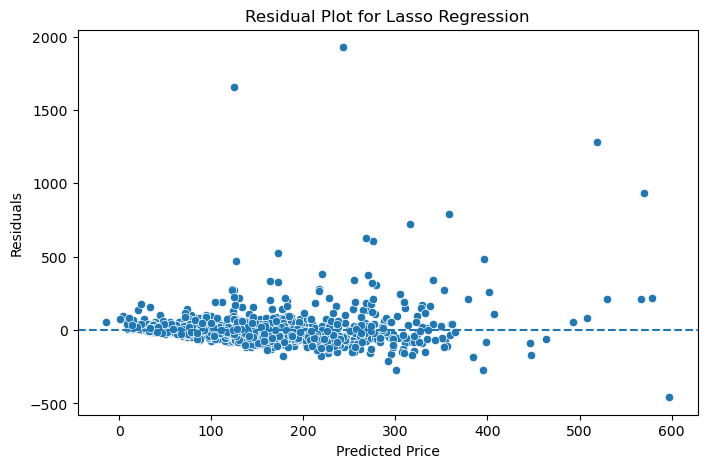

In [66]:
residuals = y_val - y_pred_selected

plt.figure(figsize=(8,5))
sns.scatterplot(x=y_pred_selected, y=residuals)
plt.axhline(0, linestyle="--")
plt.title(f"Residual Plot for {selected_name}")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.show()

The residual plot displays how prediction errors are distributed. Ideally, residuals should be randomly scattered around zero. In this case, most residuals are centred around zero, but there is some visible spread as predicted prices increase. This suggests that the model captures the general trend of the data but struggles with higher priced listings and may not fully model all underlying relationships. The presence of some structure indicates that there may still be patterns in the data that the model has not captured.

**Actual vs Predicted Plot**

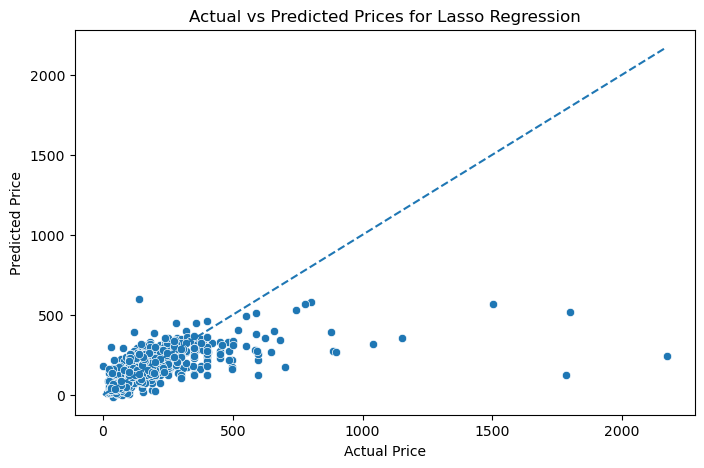

In [68]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_val, y=y_pred_selected)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], linestyle="--")
plt.title(f"Actual vs Predicted Prices for {selected_name}")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

The "Actual vs Predicted..." plot compares true prices with model predictions. Points that lie close to the line represent accurate predictions. From the plot, many predictions cluster around lower price ranges. 

- Higher-priced listings are often underestimated
- There is noticeable spread away from the diagonal line

=> This indicates that the model performs better for lower-priced listings but struggles with expensive properties, limitations in capturing complex pricing patterns

This behaviour is consistent with the earlier observation of a right-skewed price distribution.

### 12. Final Model 

The selected model (Lasso) is retrained using the full training dataset. This ensures that all available labelled data is used before generating predictions, which can improve model performance. The same preprocessing pipeline is applied to maintain consistency and avoid data leakage.

In [71]:
final_model = lasso_model

final_model.fit(X, y)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### 13. Prediction using chosen model

The trained model is used to generate predictions for the test dataset. Since the test data does not include the target variable (price), these predictions represent the final output of the model.

In [70]:
y_test_pred = final_model.predict(X_test_final)

In [72]:
pred_df = pd.DataFrame({"price": y_test_pred})
pred_df.to_csv("s4085541_predictions.csv", index=False)
pred_df.head()

,price
0,24.891241
1,128.745471
2,64.283836
3,18.070420
4,84.188302


### 14. Rationale for the Approach

This workflow follows a standard supervised machine learning pipeline. The use of a preprocessing pipeline ensures that transformations are applied consistently, reducing the risk of data leakage. Splitting the data into training and validation sets allows for a more reliable evaluation of model performance on unseen data. The comparison of Linear, Ridge, and Lasso Regression provides insight into whether regularisation improves performance. However, results show only marginal differences, suggesting that model performance is more limited by the dataset than the choice of model. Overall, the approach prioritises simplicity, interpretability, and reproducibility.

### 16. Final evaluation

The selected model achieves a validation R² of approximately 0.39, indicating moderate predictive performance. While the model captures general trends in the data, it does not fully explain the variation in Airbnb prices. This is likely due to:
- the complexity of real-world pricing
- missing important features (location quality, amenities, demand)
- limitations of linear models

The model performs better for lower-priced listings but struggles with high-value properties.

Therefore, while the model provides a reasonable baseline, more advanced models or additional features would be required to achieve stronger predictive performance.